# Does the NN residual extrapolate to unseen speeds?

The paper's `*` experiment ([RSS21_Bauersfeld.md:486](../../papers/RSS21_Bauersfeld.md)):

> "each approach is trained on two datasets: the entire training set as explained in Section IV and a reduced dataset that only covers linear speeds up to 5 m s⁻¹. This reduced dataset is used to identify new parameters for each approach, which are marked with an asterisk."

Their result is a **1.64x** force-RMSE degradation (0.335 → 0.549 N), vs 2.73x for pure learning and 6.6x for PolyFit.

Default BEM throughout, no CMA-ES tune — only the NN training data differs.

| arm | training data | windows |
|---|---|---|
| **full** | everything | 1,275,057 |
| **slow** | whole segments with max ≤ 5 m/s | 286,068 |
| **ctrl** | random whole segments, size-matched to `slow` | 297,513 |
| **win** | every 50 ms window that stays ≤ 5 m/s | 802,035 |

The paper never says at what granularity it cut. `slow` and `win` are the two readings: dropping whole gentle trajectories also strips high body rates and rotor speeds, while keeping the slow *moments* of fast flights retains them. `slow` extrapolates in all three network inputs, `win` in velocity only.

`ctrl` holds size fixed against `slow`, separating envelope from data volume — a control the paper never ran.

All arms evaluate on the same 13 held-out segments (3.5 → 17.7 m/s). Segment sets built by [speed_envelope.py](speed_envelope.py); the window cut is `dataloading.max_speed`.

In [11]:
import glob, importlib.util, os, sys
from pathlib import Path

import numpy as np
import pandas as pd

NBEM = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'processed_data').exists())
os.chdir(NBEM / 'code' / 'Python')

# analysis/utils.py shadows the code/Python/utils namespace package (no __init__.py),
# so drop any analysis dir from sys.path and evict the cached `utils` before importing.
analysis_dir = str(NBEM / 'analysis')
sys.path[:] = [p for p in sys.path if p not in (analysis_dir, '')]
for m in [k for k in sys.modules if k == 'utils' or k.startswith('utils.')]:
    del sys.modules[m]

sys.path.insert(0, str(NBEM / 'code' / 'Python'))
from generate_ablation_study import run_inference

spec = importlib.util.spec_from_file_location('measure_bem_RMSE', str(NBEM / 'analysis' / 'measure_bem_RMSE.py'))
mbr = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mbr)
metrics = mbr.metrics

%matplotlib inline

In [12]:
# each arm needs its own test folder: same 13 segments, but loader.py matches on the base_type prefix
ARMS = {
    'full': ('train_logs/20260708-223500', 'data/bem/test'),
    'slow': ('train_logs/20260804-180945', 'data/bem-slow/test'),
    'ctrl': ('train_logs/20260804-181142', 'data/bem-ctrl/test'),
    'win':  ('train_logs/20260805-111733', 'data/bem/test'),
}
NONE = {
    'full': ('train_logs/20260805-145141', 'data/none/test'),
}


def row(res):
    fxy, fz, F = metrics(res[:, 0:3])
    mxy, mz, M = metrics(res[:, 3:6])
    return {'Fxy': fxy, 'Fz': fz, 'Mxy': mxy, 'Mz': mz, 'F': F, 'M': M}


rows, bem_row = {}, None
for name, (lf, dr) in ARMS.items():
    preds, labels, _ = run_inference(lf, dr)
    bem_row = row(labels)
    rows['BEM+NN ' + name] = row(labels - preds)
rows = {'BEM (no NN)': bem_row, **rows}

for name, (lf, dr) in NONE.items():
    preds, labels, _ = run_inference(lf, dr)
    rows['None+NN ' + name] = row(labels - preds)

#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 13 experiments.
Decoding data...


100%|██████████| 13/13 [00:00<00:00, 14.30it/s]


Highest angular speed observed in the dataset: 15.318 rad/s
Highest linear speed observed in the dataset: 17.724 m/s
Highest residual force observed in the dataset: 17.200 N
Highest residual torque observed in the dataset: 0.745 Nm
Found 1691 samples assembled from 215829 raw data points belonging to 13 experiments:


100%|██████████| 1691/1691 [00:11<00:00, 153.07it/s]


#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 13 experiments.
Decoding data...


...

100%|██████████| 1691/1691 [00:10<00:00, 165.94it/s]


#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 13 experiments.
Decoding data...


100%|██████████| 13/13 [00:00<00:00, 16.02it/s]


Highest angular speed observed in the dataset: 15.318 rad/s
Highest linear speed observed in the dataset: 17.724 m/s
Highest residual force observed in the dataset: 36.202 N
Highest residual torque observed in the dataset: 0.618 Nm
Found 1691 samples assembled from 215829 raw data points belonging to 13 experiments:


100%|██████████| 1691/1691 [00:10<00:00, 165.97it/s]


In [13]:
COLS = ['Fxy', 'Fz', 'Mxy', 'Mz', 'F', 'M']
df = pd.DataFrame(rows).T[COLS]
df.index.name = 'model'

PAPER = pd.DataFrame({
    'BEM+NN (paper)':   {'Fxy': 0.204, 'Fz': 0.504, 'Mxy': 0.014, 'Mz': 0.004, 'F': 0.335, 'M': 0.012},
    'BEM+NN* (paper)':  {'Fxy': 0.344, 'Fz': 0.816, 'Mxy': 0.025, 'Mz': 0.008, 'F': 0.549, 'M': 0.021},
    'None+NN (paper)':  {'Fxy': 0.236, 'Fz': 0.681, 'Mxy': 0.017, 'Mz': 0.002, 'F': 0.438, 'M': 0.014},
    'None+NN* (paper)': {'Fxy': 0.470, 'Fz': 1.959, 'Mxy': 0.007, 'Mz': 0.002, 'F': 1.194, 'M': 0.006},
}).T[COLS]

out = pd.concat([df, PAPER])


def ref(k):
    if '(paper)' in k:
        return 'None+NN (paper)' if k.startswith('None') else 'BEM+NN (paper)'
    return 'None+NN full' if k.startswith('None') else 'BEM+NN full'


base = [ref(k) for k in out.index]
out['F x full'] = out['F'].values / out.loc[base, 'F'].values
out['M x full'] = out['M'].values / out.loc[base, 'M'].values

(out.style
    .format({c: '{:.3f}' for c in COLS} | {'F x full': '{:.2f}x', 'M x full': '{:.2f}x'})
    .apply(lambda s: ['color: #c62828' if v > 1.05 else 'color: #2e7d32' if v < 1.05 else ''
                      for v in s], subset=['F x full', 'M x full'])
    .set_caption('Test-set RMSE, paper Table II format. "x full" = degradation vs the full-data arm of the same base model.'))

,Fxy,Fz,Mxy,Mz,F,M,F x full,M x full
BEM (no NN),0.575,1.664,0.127,0.015,1.069,0.104,3.03x,13.65x
BEM+NN full,0.193,0.547,0.009,0.002,0.353,0.008,1.00x,1.00x
BEM+NN slow,0.444,1.482,0.048,0.008,0.929,0.040,2.63x,5.18x
BEM+NN ctrl,0.235,0.622,0.015,0.003,0.407,0.012,1.15x,1.58x
BEM+NN win,0.310,1.180,0.022,0.004,0.727,0.018,2.06x,2.42x
None+NN full,0.207,0.744,0.003,0.002,0.462,0.003,1.00x,1.00x
BEM+NN (paper),0.204,0.504,0.014,0.004,0.335,0.012,1.00x,1.00x
BEM+NN* (paper),0.344,0.816,0.025,0.008,0.549,0.021,1.64x,1.75x
None+NN (paper),0.236,0.681,0.017,0.002,0.438,0.014,1.00x,1.00x
None+NN* (paper),0.470,1.959,0.007,0.002,1.194,0.006,2.73x,0.43x


## Where it breaks

Force RMSE per held-out segment vs that segment's max speed. The aggregate above averages 3.5 to 17.7 m/s and hides the shape.

In [14]:
per_seg = {}
for name, (lf, dr) in ARMS.items():
    for f in sorted(glob.glob(os.path.join(dr, '*.csv'))):
        sid = os.path.basename(f).split('_', 1)[1][:-4]
        preds, labels, _ = run_inference(lf, f)
        d = np.loadtxt(f, delimiter=',', usecols=(14, 15, 16))
        res = labels - preds
        per_seg.setdefault(sid, {'vmax': np.linalg.norm(d, axis=1).max()})
        per_seg[sid][name] = np.sqrt((res[:, 0:3] ** 2).sum(1).mean())
        per_seg[sid]['BEM'] = np.sqrt((labels[:, 0:3] ** 2).sum(1).mean())

seg = pd.DataFrame(per_seg).T.sort_values('vmax')
seg

#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 1 experiments.
Decoding data...


100%|██████████| 1/1 [00:00<00:00, 16.24it/s]


Highest angular speed observed in the dataset: 2.764 rad/s
Highest linear speed observed in the dataset: 9.693 m/s
Highest residual force observed in the dataset: 3.717 N
Highest residual torque observed in the dataset: 0.343 Nm
Found 132 samples assembled from 16797 raw data points belonging to 1 experiments:


100%|██████████| 132/132 [00:00<00:00, 150.29it/s]


#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 1 experiments.
Decoding data...


...

#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 1 experiments.
Decoding data...


100%|██████████| 1/1 [00:00<00:00, 13.82it/s]


Highest angular speed observed in the dataset: 3.508 rad/s
Highest linear speed observed in the dataset: 16.537 m/s
Highest residual force observed in the dataset: 6.902 N
Highest residual torque observed in the dataset: 0.664 Nm
Found 132 samples assembled from 16909 raw data points belonging to 1 experiments:


100%|██████████| 132/132 [00:00<00:00, 139.89it/s]


,vmax,full,BEM,slow,ctrl,win
2021-02-23-10-48-03_seg_2,3.454576,0.264194,0.206760,0.266103,0.218988,0.192500
2021-02-18-17-03-20_seg_2,6.515827,0.193993,0.548282,0.449630,0.174255,0.235118
2021-02-23-11-41-38_seg_3,6.801857,0.346730,0.759936,0.548465,0.298834,0.414076
2021-02-23-22-26-25_seg_2,8.823780,0.451316,1.214851,1.072083,0.653110,0.528804
2021-02-18-13-44-23_seg_2,9.693033,0.352840,1.029380,0.743218,0.402436,0.497057
2021-02-18-17-19-08_seg_2,11.264218,0.410615,1.367885,1.203421,0.578981,1.037334
2021-02-18-18-08-45_seg_1,11.810194,0.313354,1.432835,1.218658,0.371365,0.769739
2021-02-23-19-45-06_seg_2,12.149685,0.794237,1.630698,2.255058,0.913259,1.437930
2021-02-23-14-21-48_seg_3,13.608925,0.658968,2.302153,2.241346,0.655494,1.462410
2021-02-18-17-26-00_seg_1,14.260971,0.582977,2.299973,1.589526,0.947685,1.451565


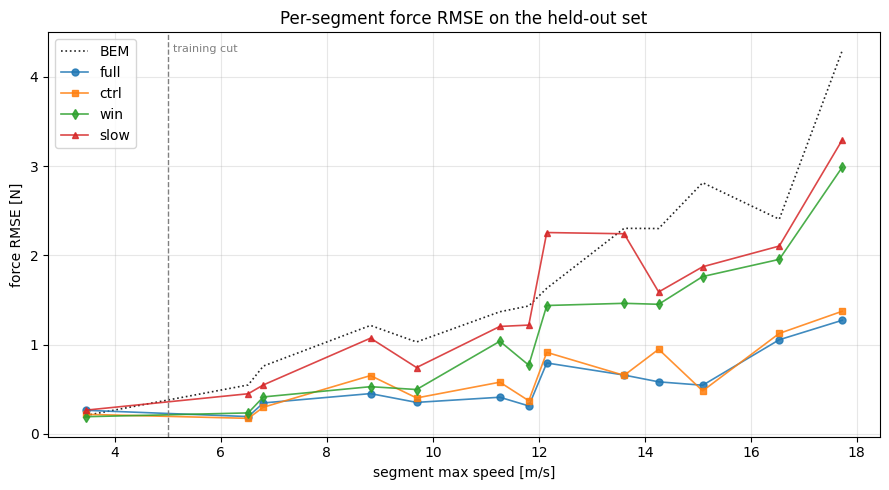

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for name, style in [('BEM', 'k:'), ('full', 'o-'), ('ctrl', 's-'), ('win', 'd-'), ('slow', '^-')]:
    ax.plot(seg['vmax'], seg[name], style, lw=1.2, ms=5, alpha=0.85, label=name)
ax.axvline(5.0, color='gray', ls='--', lw=1)
ax.text(5.1, ax.get_ylim()[1] * 0.95, 'training cut', fontsize=8, color='gray')
ax.set_xlabel('segment max speed [m/s]')
ax.set_ylabel('force RMSE [N]')
ax.set_title('Per-segment force RMSE on the held-out set')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()